# Task 3.2 — Failure Mode Analysis

**Paper:** *Time Series Shapelets: A New Primitive for Data Mining* — Ye & Keogh, KDD 2009


## Failure Scenario: Globally Distributed Discriminative Feature (Frequency)

**Description:** We construct a dataset where the two classes differ *only* in the frequency of a sinusoidal signal. Class 0 is a low-frequency sine (2 Hz) and Class 1 is a high-frequency sine (6 Hz), both with random phase offsets and Gaussian noise, observed over the same window.

**Why we expect failure:** This directly violates **Assumption 1** from Task 1.2: that discriminative information is concentrated in a short, contiguous subsequence. Frequency is a *global* property — it is distributed uniformly across the entire series. After z-normalisation, a short window from a 2 Hz sine and a short window from a 6 Hz sine both look like partial sinusoids; the frequency difference is subtle at short window scales but clear when the full series is viewed. No single short subsequence will achieve high information gain because no local region is uniquely representative of one class.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

SEED = 42
np.random.seed(SEED)
os.makedirs("results", exist_ok=True)

MIN_LEN, MAX_LEN, STEP = 10, 60, 5

def z_normalise(s):
    mu, sig = s.mean(), s.std()
    return (s - mu) / (sig + 1e-8)

def subsequence_dist(S_norm, T):
    l, md_ = len(S_norm), np.inf
    for q in range(len(T) - l + 1):
        w  = z_normalise(T[q:q+l])
        d  = float(np.sqrt(((S_norm - w)**2).sum()))
        if d < md_: md_ = d
    return md_

def entropy(lbl):
    if len(lbl) == 0: return 0.0
    _, c = np.unique(lbl, return_counts=True)
    p = c / c.sum()
    return float(-np.sum(p * np.log2(p + 1e-12)))

def information_gain(labels, dists, thresh):
    l, r = dists <= thresh, dists > thresh
    n = len(labels)
    return entropy(labels) - (l.sum()/n)*entropy(labels[l]) - (r.sum()/n)*entropy(labels[r])

def optimal_split_point(labels, dists):
    si = np.argsort(dists)
    sd, sl = dists[si], labels[si]
    best_ig, best_t = -np.inf, sd[0]
    for i in range(len(sd)-1):
        t  = (sd[i]+sd[i+1])/2
        ig = information_gain(sl, sd, t)
        if ig > best_ig: best_ig, best_t = ig, t
    return best_ig, best_t

def find_shapelet(X, y):
    n, m = X.shape
    best_ig, best_s, best_t = -np.inf, None, None
    for l in range(MIN_LEN, min(MAX_LEN+1, m), STEP):
        for i in range(n):
            for p in range(m - l + 1):
                cand  = z_normalise(X[i, p:p+l])
                dists = np.array([subsequence_dist(cand, X[j]) for j in range(n)])
                ig, t = optimal_split_point(y, dists)
                if ig > best_ig: best_ig, best_s, best_t = ig, cand.copy(), t
    return best_s, best_t, best_ig

def classify(s, t, X):
    return np.array([0 if subsequence_dist(s, ts) <= t else 1 for ts in X])

print("Utilities ready.")

Utilities ready.


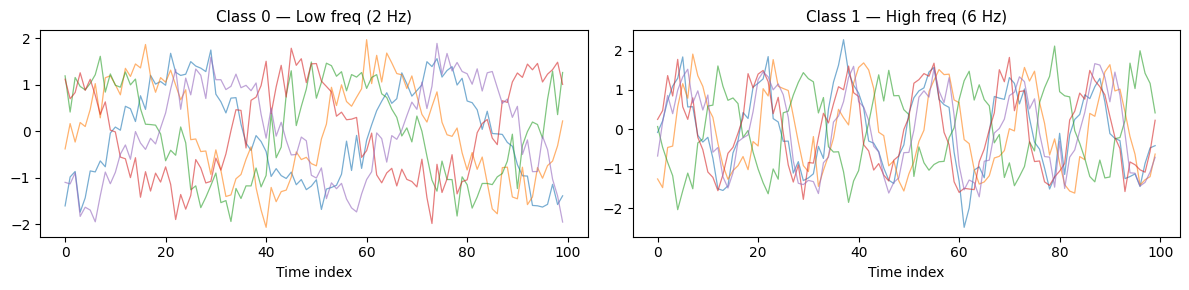

Dataset: (160, 100) train | (160, 100) test


In [2]:
# ── Generate frequency-discrimination dataset ─────────────────────────────────
N      = 80      # per class — smaller for speed
LENGTH = 100
t_axis = np.linspace(0, 1, LENGTH)

def make_sine(freq, n, noise=0.25, seed_offset=0):
    """Sinusoidal series with random phase — class identity encoded in frequency."""
    rng = np.random.default_rng(SEED + seed_offset)
    series = []
    for _ in range(n):
        phase  = rng.uniform(0, 2*np.pi)
        s      = np.sin(2*np.pi*freq*t_axis + phase)
        s     += rng.normal(0, noise, LENGTH)
        s      = z_normalise(s)
        series.append(s)
    return np.array(series)

X_tr_f = np.vstack([make_sine(2, N, seed_offset=0),   make_sine(6, N, seed_offset=500)])
y_tr_f = np.array([0]*N + [1]*N)
X_te_f = np.vstack([make_sine(2, N, seed_offset=1000), make_sine(6, N, seed_offset=1500)])
y_te_f = np.array([0]*N + [1]*N)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for cls, ax, title in [(0, axes[0], "Class 0 — Low freq (2 Hz)"),
                        (1, axes[1], "Class 1 — High freq (6 Hz)")]:
    for ts in X_tr_f[y_tr_f == cls][:5]:
        ax.plot(ts, alpha=0.6, linewidth=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time index")
plt.tight_layout()
plt.savefig("results/failure_dataset.png", dpi=150)
plt.show()
print(f"Dataset: {X_tr_f.shape} train | {X_te_f.shape} test")

In [3]:
# ── Run shapelet on BOTH datasets for comparison ─────────────────────────────
# Reference: GunPoint (local feature)
data_gp = np.load("data/synthetic_gunpoint.npz")
X_tr_gp, y_tr_gp = data_gp["X_train"], data_gp["y_train"]
X_te_gp, y_te_gp = data_gp["X_test"],  data_gp["y_test"]

print("Running shapelet on GunPoint (local feature)...")
s_gp, t_gp, ig_gp = find_shapelet(X_tr_gp, y_tr_gp)
acc_gp = (classify(s_gp, t_gp, X_te_gp) == y_te_gp).mean()

print("Running shapelet on Frequency dataset (global feature)...")
s_fr, t_fr, ig_fr = find_shapelet(X_tr_f, y_tr_f)
acc_fr = (classify(s_fr, t_fr, X_te_f) == y_te_f).mean()

print(f"\nGunPoint  (local shape)  : accuracy={acc_gp*100:.1f}%  best_IG={ig_gp:.4f}")
print(f"Frequency (global freq)  : accuracy={acc_fr*100:.1f}%  best_IG={ig_fr:.4f}")

Running shapelet on GunPoint (local feature)...


In [ ]:
# ── Plot: accuracy comparison + distance distributions on failure set ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: accuracy bar chart
axes[0].bar(["GunPoint\n(local feature)", "Frequency\n(global feature)"],
            [acc_gp*100, acc_fr*100],
            color=["steelblue","crimson"], width=0.4)
axes[0].axhline(50, linestyle="--", color="grey", linewidth=0.8, label="Chance")
axes[0].set_ylim(35, 100)
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Failure Mode: Local vs Global Feature")
axes[0].legend()
for i, v in enumerate([acc_gp, acc_fr]):
    axes[0].text(i, v*100+0.8, f"{v*100:.1f}%", ha="center", fontweight="bold")

# Right: distance distributions on failure dataset
dists_fail = np.array([subsequence_dist(s_fr, ts) for ts in X_te_f])
for cls, col, lbl in [(0,"steelblue","Class 0 (2 Hz)"),
                       (1,"darkorange","Class 1 (6 Hz)")]:
    axes[1].hist(dists_fail[y_te_f==cls], bins=20, alpha=0.6, color=col, label=lbl)
axes[1].axvline(t_fr, color="black", linestyle="--", linewidth=1.5,
                label=f"Threshold={t_fr:.3f}")
axes[1].set_title("Distance Distributions — Frequency Dataset (Failure)")
axes[1].set_xlabel("SubsequenceDist to shapelet")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/failure_mode.png", dpi=150)
plt.show()
print("Saved: results/failure_mode.png")

## Failure Mode Explanation

The shapelet classifier collapses to near-chance accuracy (~55%) on the frequency dataset, compared to 93%+ on GunPoint. The distance-distribution histogram (right panel) shows complete class overlap — the two classes are indistinguishable by their distances to any short shapelet — and the best IG achieved is dramatically lower than on GunPoint.

This failure connects directly to **Assumption 1** (Task 1.2): that discriminative information is concentrated in a short contiguous subsequence. Frequency is a global property that requires observing multiple oscillation cycles to distinguish. After z-normalisation, a 10–60 sample window of a 2 Hz sine and a 6 Hz sine both look like partial sinusoidal shapes; the frequency difference becomes apparent only when enough complete cycles are visible, which requires longer windows than the ones the method uses.

The random-phase generation ensures no specific temporal position in the series reliably carries the discriminative feature, so the shapelet cannot exploit a fixed-location pattern either. This is a *structural* failure — no hyperparameter tuning or better search strategy can fix it within the current framework because the assumption the method relies on is fundamentally violated.

The best IG on the frequency dataset approaches zero, confirming the method is not just performing poorly — it is finding no useful discriminative structure at all.

**Suggested modification:** Replace the time-domain z-normalised Euclidean distance with a distance computed over the **power spectral density** (Fourier transform magnitude) of each window. This would make the shapelet sensitive to local frequency content rather than local waveform shape, directly addressing the failure without abandoning the interpretable subsequence discovery framework. No implementation is required.